# Income Prediction

<br>

## Import & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

## Summary

<br>

## Introduction

Wine is one of the most widely consumed beverages in the world, valued for its taste, cultural significance, and sensory qualities. Determining wine quality, even for expert tasters, can be challenging.

[Vinho verde wine](https://en.wikipedia.org/wiki/Vinho_Verde) is produced in the Minho region of northern Portugal and is known for its light and fresh characteristics. In this project, we focus on white vinho verde wine and investigate whether its physicochemical properties can be used to predict wine quality.

To answer this question, we use a dataset from the UC Irvine Machine Learning Repository [(Cortez et al., 2009)](https://archive-beta.ics.uci.edu/dataset/186/wine+quality) and apply predictive modeling techniques to explore relationships between chemical measurements and sensory quality scores.<br>

### Dataset Description

The Wine Quality dataset contains physicochemical measurements of Portuguese *Vinho Verde* wines. Each observation corresponds to a wine sample that was evaluated using laboratory tests and sensory analysis by wine experts.

The dataset includes 11 physicochemical input variables (e.g., acidity, pH, alcohol content) and 1 target variable representing wine quality.

Wine quality scores were assigned as the median of at least three expert evaluations, with ratings ranging from 0 (very bad) to 10 (excellent).

Two datasets exist in the Wine Quality dataset collection:
- **Red wine:** 1,599 observations  
- **White wine:** 4,898 observations  

For this analysis, we **only use the white wine dataset**.


#### Feature Description

| Name | Role | Type | Units | Description | Missing Values |
|-----|-----|-----|-----|-----|-----|
| fixed_acidity | Feature | Continuous | g/dm³ | Fixed acids (primarily tartaric acid) that do not evaporate easily. | No |
| volatile_acidity | Feature | Continuous | g/dm³ | Amount of acetic acid in wine; high levels can lead to an unpleasant vinegar taste. | No |
| citric_acid | Feature | Continuous | g/dm³ | Citric acid content, which can add freshness and flavor to wine. | No |
| residual_sugar | Feature | Continuous | g/dm³ | Amount of sugar remaining after fermentation stops. | No |
| chlorides | Feature | Continuous | g/dm³ | Salt content in the wine. | No |
| free_sulfur_dioxide | Feature | Continuous | mg/dm³ | Free form of sulfur dioxide that prevents microbial growth and oxidation. | No |
| total_sulfur_dioxide | Feature | Continuous | mg/dm³ | Total amount of sulfur dioxide (free + bound forms). | No |
| density | Feature | Continuous | g/cm³ | Density of the wine, influenced by alcohol and sugar content. | No |
| pH | Feature | Continuous | – | Acidity level of the wine; lower values indicate higher acidity. | No |
| sulphates | Feature | Continuous | g/dm³ | Potassium sulphate concentration, contributing to sulfur dioxide levels and preservation. | No |
| alcohol | Feature | Continuous | % (vol) | Alcohol content of the wine. | No |
| quality | Target | Integer | Score (0–10) | Wine quality score based on expert sensory evaluation. | No

## Methods

### Exploratory Data Analysis

#### Loading the Dataset

The Wine Quality dataset is retrieved directly from the **UCI Machine Learning Repository** using the `ucimlrepo` library. The dataset is returned with the features (input variables) and the target variable (wine quality score) stored separately.  

To recreate the original dataset structure, we combine the features and target into a single DataFrame using `pd.concat()`. This produces a table where each row represents a wine sample and each column represents a physicochemical property or the quality score.

In [2]:
# Fetch dataset
wine_quality = fetch_ucirepo(id=186)

# Features and target
X = wine_quality.data.features
y = wine_quality.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### Inspecting the dataset structure

We examine the basic structure of the dataset by checking its shape, column names, data types, and whether any values are missing.

- `df.shape` shows the number of rows and columns in the dataset.
- `df.columns` lists all variable names.
- `df.info()` provides the data type of each column and a summary of non-null values.
- `df.isnull().sum()` counts the number of missing values in each column.
- `df.describe()` provides summary statistics such as mean, standard deviation, and range for numerical variables.

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types and info:")
print(df.info())

Shape of dataset: (6497, 12)

Column names:
Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [5]:
print("Summary statistics:")
print(df.describe())

Summary statistics:
       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000          

#### Distribution of wine quality

We visualize the distribution of the target variable `quality` using a bar chart. The values are counted using `value_counts()` and sorted by quality score to show how many wines fall into each rating category. This helps us understand how wine quality scores are distributed across the dataset.

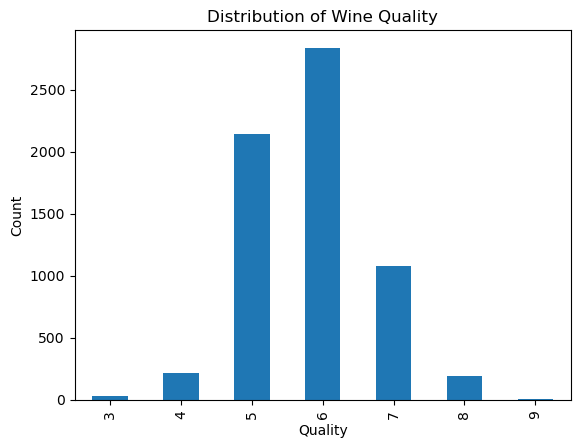

In [6]:
plt.figure()
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

The distribution of wine quality scores is concentrated around the middle values. Most wines are rated 5 or 6, with quality 6 being the most frequent. Very few wines receive extreme ratings such as 3 or 9, indicating that the dataset contains mostly average-quality wines and relatively few very poor or excellent samples.

### Feature distributions

We generate histograms for each numerical feature in the dataset using `df.hist()`. This allows us to visualize the distribution of values for each variable and observe patterns such as skewness, spread, and potential outliers across the physicochemical properties of the wines.

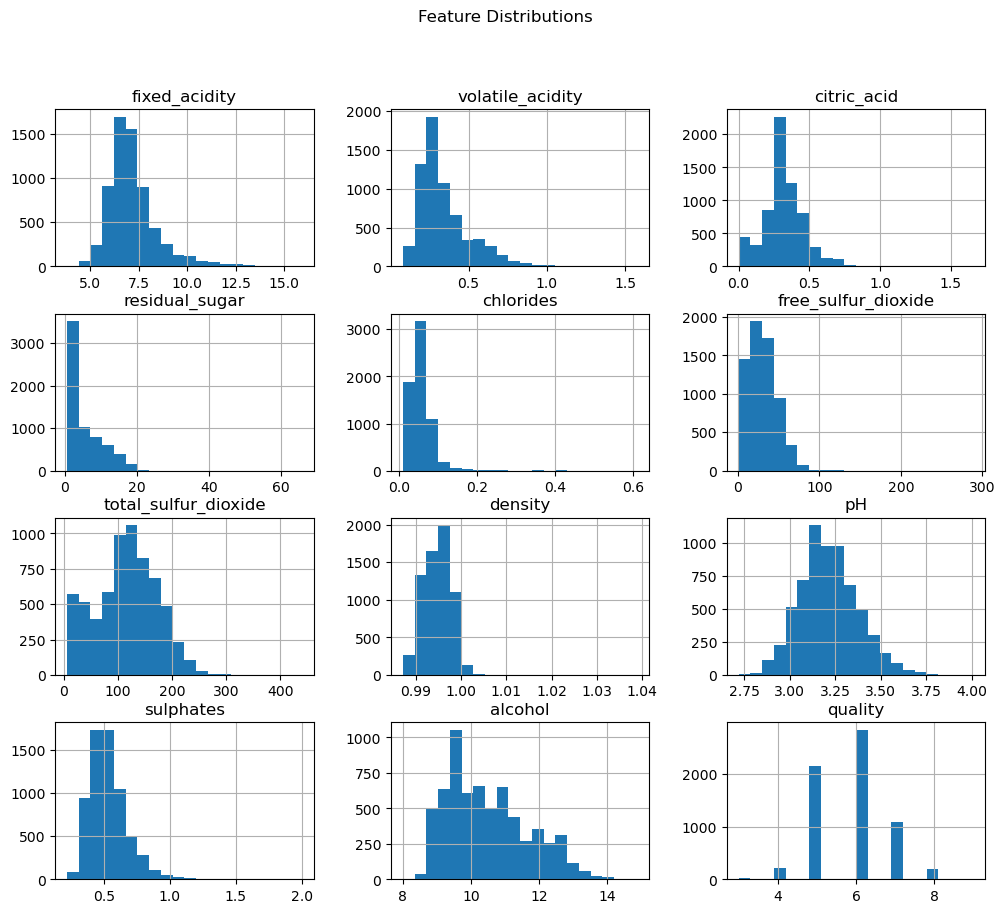

In [7]:
df.hist(bins=20, figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

The summary statistics show that most physicochemical variables fall within fairly narrow ranges. For example, pH values are centered around 3.2 with a small spread, and density is close to 0.995 for most wines. Alcohol content ranges roughly from 8% to 15%, with an average around 10.5%. In contrast, residual sugar varies much more widely, ranging from under 1 to over 60, indicating some extreme observations.

The skewness values suggest that several variables are right-skewed, meaning most wines have lower values with a few larger observations. This pattern is especially noticeable for chlorides, residual sugar, sulphates, and fixed acidity. Total sulfur dioxide appears approximately symmetric.

The skewness values suggest that several variables are right-skewed, meaning most wines have lower values with a few much larger observations. This pattern is especially noticeable for chlorides, residual sugar, sulphates, and fixed acidity. Total sulfur dioxide appears roughly symmetric, meaning its values are more evenly distributed around the average.

#### Correlation matrix

We compute the correlation matrix using `df.corr()` to measure the linear relationships between all numerical variables in the dataset. The matrix is then visualized using `plt.imshow()`, where each cell represents the correlation between two variables.

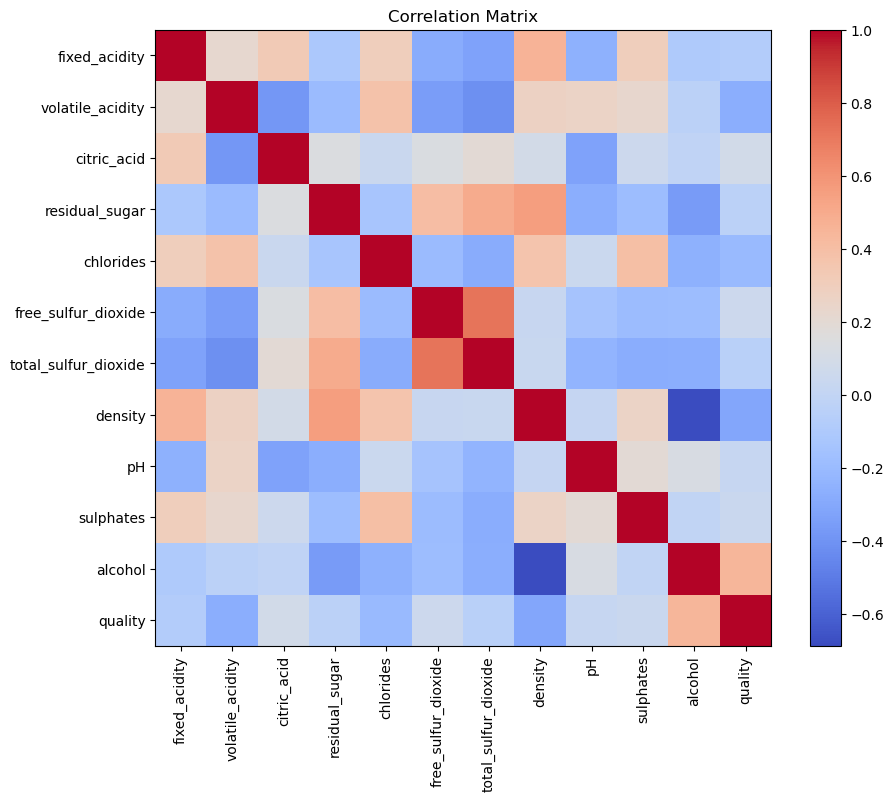

In [8]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows the strength and direction of linear relationships between the variables. Overall, most physicochemical features have relatively weak correlations with wine quality, suggesting that quality is influenced by multiple factors rather than a single dominant variable. Alcohol content tends to have a positive relationship with quality, while variables such as volatile acidity and density show negative relationships. Many of the input variables also show moderate correlations with each other, indicating that some chemical properties of the wine are related.

## Results

<br>

## Discussion

<br>

## References

Modeling wine preferences by data mining from physicochemical properties
P. Cortez, A. Cerdeira, Fernando Almeida, Telmo Matos, J. Reis. 2009.
Decision Support Systems
https://archive-beta.ics.uci.edu/dataset/186/wine+quality


Wikipedia contributors. (2025). *Vinho Verde*. 
https://en.wikipedia.org/wiki/Vinho_Verde